Saving train.csv to train (2).csv


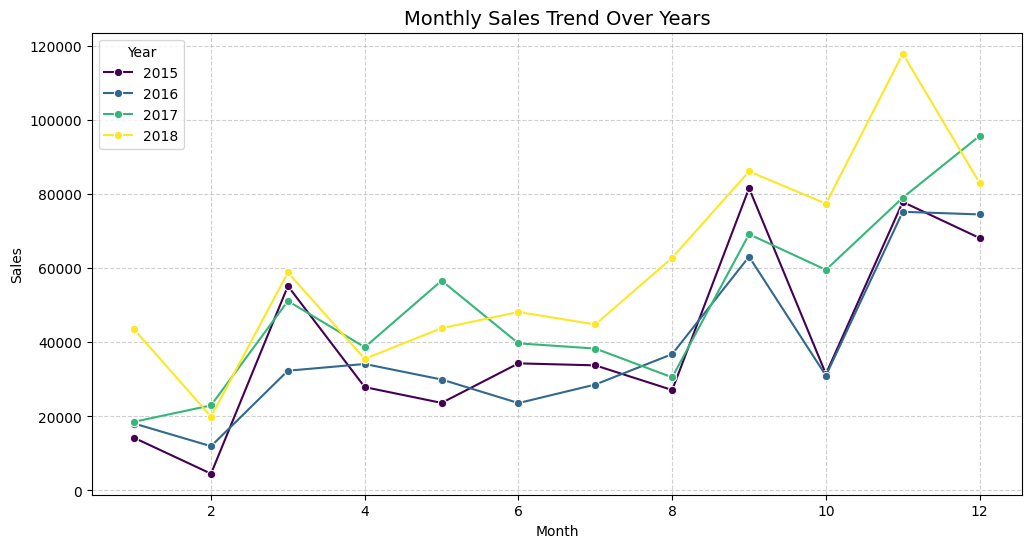

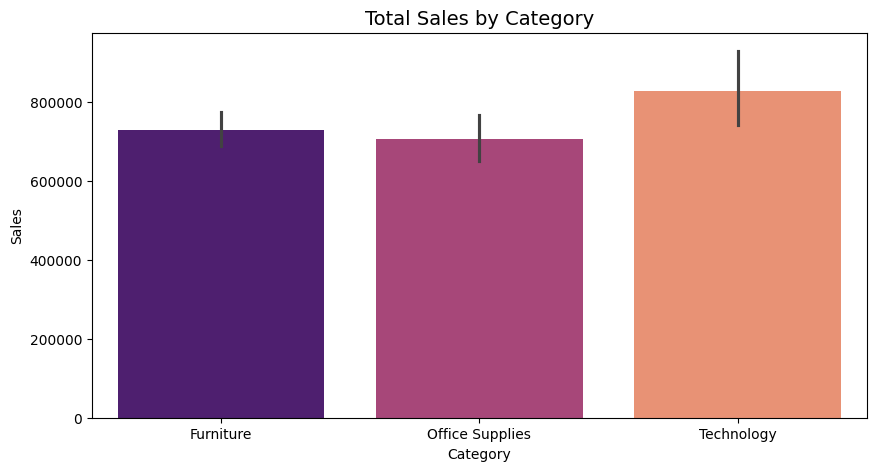

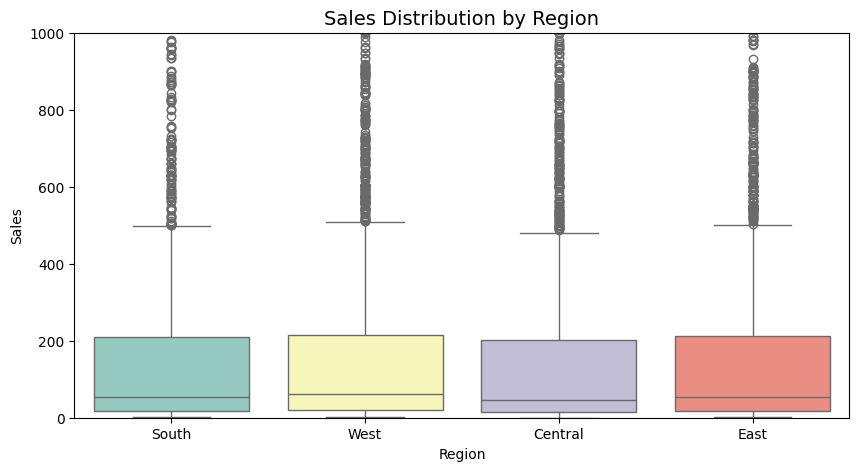

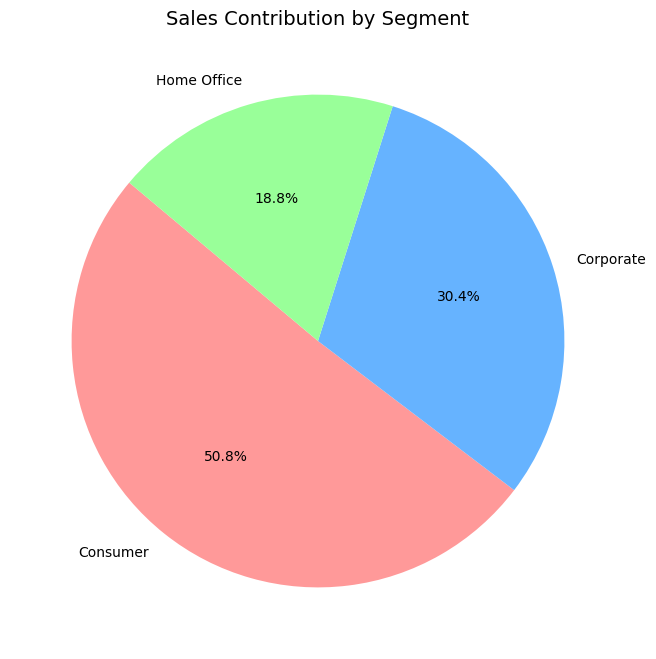

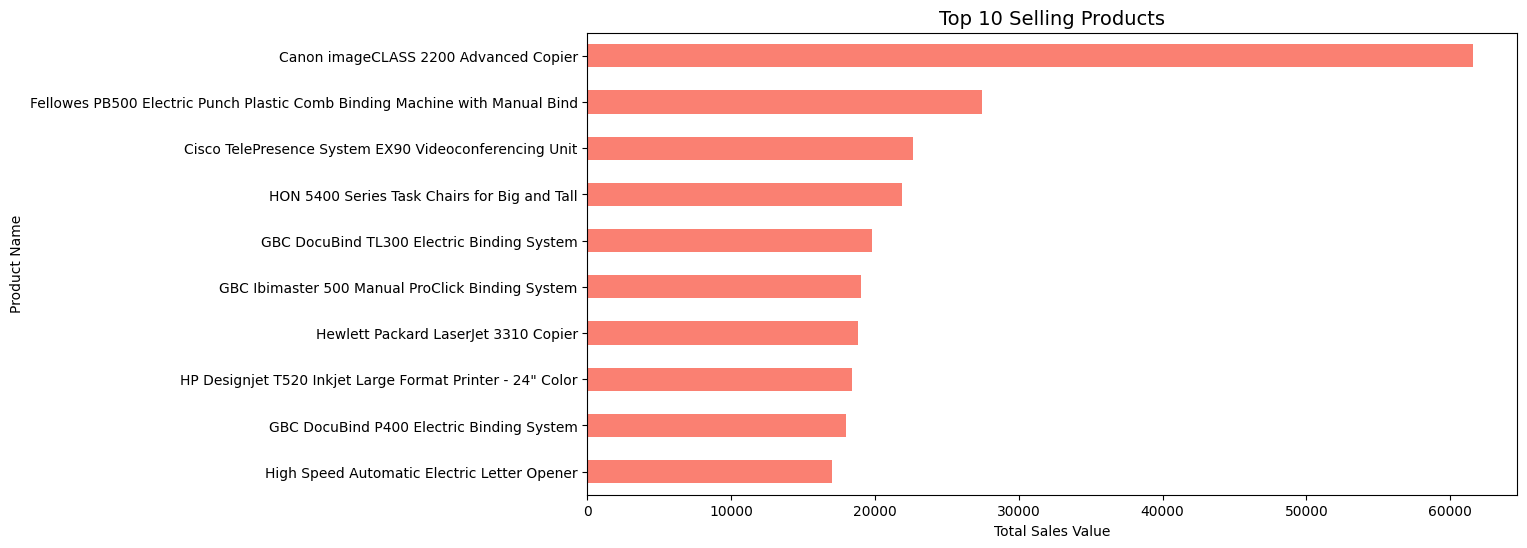


📊 Business Summary Stats:
Total Revenue:  $2,261,536.78
Top Selling Region: West
Top Selling Segment: Consumer


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


uploaded = files.upload()


df = pd.read_csv('train.csv', encoding='latin1')


df.columns = df.columns.str.strip()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year


monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o', palette='viridis')
plt.title('Monthly Sales Trend Over Years', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, palette='magma', hue='Category', legend=False)
plt.title('Total Sales by Category', fontsize=14)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Region', y='Sales', data=df, palette='Set3', hue='Region', legend=False)
plt.ylim(0, 1000)
plt.title('Sales Distribution by Region', fontsize=14)
plt.show()


plt.figure(figsize=(8, 8))
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Sales Contribution by Segment', fontsize=14)
plt.show()

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='salmon').invert_yaxis()
plt.title('Top 10 Selling Products', fontsize=14)
plt.xlabel('Total Sales Value')
plt.show()

print("\n" + "="*40)
print("📊 Business Summary Stats:")
print(f"Total Revenue:  ${df['Sales'].sum():,.2f}")
print(f"Top Selling Region: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Top Selling Segment: {segment_sales.idxmax()}")
print("="*40)